## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

"What extent do NBA Draft Combine athletic measurements predict players' first five years of career performance, after controlling for draft position and college statistics?"



## Background and Prior Work

The NBA Draft Combine is a key tool for teams to assess physical and skill-based attributes of potential players. It conducts evaluations through standardized measurements and athletic tests, like height, wingspan, vertical jump, sprint speed, and on-court drills. (1) The results of the draft combine are often used to estimate a player’s physical potential and readiness for the NBA and are also used as a supplement to the traditional assessment based on college performance. Since the combine tests can make standardized comparisons among players, it plays an important role in draft decisions.

Prior studies have shown that combined indicators do have an impact on the draft outcomes, though their importance may vary across positions. The research found that anthropometric measurements and physical performance tests can help distinguish between drafted and undrafted players, with different attributes serving as stronger predictors depending on positional role—for example, speed and agility for guards versus size and reach for frontcourt players (3). These findings indicate that teams do incorporate combined measurements into their talent evaluation processes.

However, to what extent draft combined measurements could transform into sustained NBA success is still unclear. Recent studies about NBA Draft Combine indicators have found that there is a weak or insignificant relationship between combine results and rookie performance indicators, including points, rebounds, and assists per game. (1) This finding suggests that although combined data can reflect measurable physical potential, they may not cover intangible factors such as basketball IQ, adaptability, and in-game decision-making, limiting their ability to predict early professional performance.

In contrast, other prior research has shown that draft position itself is strongly correlated with long-term career outcomes. Especially, players who rank high in the draft tend to have more playing opportunities and have longer careers in the NBA, indicating that the draft position reflects the teams' overall assessment of the players' abilities and potential. (2) Therefore, when assessing the predictive value of the draft combine, it should be controlled.

Given these findings, it is currently unclear whether draft combine measurements meaningfully predict a player’s early NBA performance after controlling for draft position and college performance. This project explores whether pre-draft combine measurements can predict a player’s on-court performance during the first five years of their NBA career.

References:

1.https://www.researchgate.net/publication/396582065_Evaluating_the_Predictive_Power_of_NBA_Draft_Combine_Metrics_on_Early-Career_Performance_An_Empirical_Analysis_from_the_20222024_Seasons

2.https://archives.rpd-online.com/article/download/v28-n3-miguel-milan-soares-etal/2746-14000-1-PB.pdf

3.https://pmc.ncbi.nlm.nih.gov/articles/PMC6820507/

# Hypothesis


 "We predict that after controlling for draft position and college statistics, NBA Draft Combine athletic measurements will have limited ability to predict players' performance during their first five years in the league. Although combined metrics influence draft decisions and help distinguish drafted from undrafted players (Reference 3), Prior research shows that draft position is strongly linked to career outcomes (Reference 2), while combine metrics have weak and often nonsignificant relationships with early career performance (Reference 1). Therefore, we expect that most combined measurements will explain little additional variation in long-term performance beyond what is already captured by draft order and college success."

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [2]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [3]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
     { 'url': 'https://raw.githubusercontent.com/MrNobodyCarez/Draft-Combine---Kaggle.csv/refs/heads/main/Draft%20Combine%20-%20Kaggle.csv', 'filename':'Draft_Combine_Kaggle.csv'},
    { 'url': 'https://raw.githubusercontent.com/GrzegorzPus/NBA_analysis/9bf80ea01119e20c5dc04983b8620981d88b7b6a/Data/draft-data-20-years.csv', 'filename': 'draft-data-20-years.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'},
    { 'url': 'https://raw.githubusercontent.com/illumitata/NBA/master/data/Seasons_Stats.csv', 
      'filename': 'Seasons_Stats.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  20%|██        | 1/5 [00:00<00:00,  8.75it/s]   

Successfully downloaded: airline-safety.csv



Overall Download Progress:  40%|████      | 2/5 [00:00<00:00,  6.86it/s]         

Successfully downloaded: Draft_Combine_Kaggle.csv



Overall Download Progress:  60%|██████    | 3/5 [00:00<00:00,  5.12it/s]       

Successfully downloaded: draft-data-20-years.csv



Overall Download Progress:  80%|████████  | 4/5 [00:00<00:00,  6.20it/s]

Successfully downloaded: bad-drivers.csv



Overall Download Progress: 100%|██████████| 5/5 [00:01<00:00,  2.66it/s]  

Successfully downloaded: Seasons_Stats.csv


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [4]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

### NBA Draft Combine Anthropometric & Athletic Measurements (Kaggle)

For Dataset #1, I am using a dataset from Kaggle titled NBA Draft Combine Anthropometric and Athletic Measurements. This dataset contains physical measurements and performance testing results for 1,678 NBA Draft Combine participants from 2000 to 2025. The NBA Draft Combine is an annual event where draft eligible players are evaluated through official body measurements and athletic drills in front of NBA teams. These measurements are important because they provide standardized, verified physical data that teams use when assessing a player's long term potential. However, it is important to consider that not all top prospects participate in every drill and some elite players skip the combine entirely if their draft position is already secured. This introduces potential selection bias into the dataset, which must be acknowledged when interpreting results.

There are many column variables included in this dataset, such as height, weight, wingspan, standing reach, body mass index, sprint time, vertical jump measurements, lane agility time, bench press repetitions, and hand measurements. While all of these variables are useful for evaluating athleticism, our project focuses specifically on core anthropometric characteristics rather than performance drill outcomes. Therefore, the columns I selected for analysis are height (height_in), weight (weight_lbs), wingspan (wingspan_in), hand length (hand_length_in), hand width (hand_width_in), and body fat percentage (body_fat_pct).

Height represents a player's barefoot measurement in inches and reflects their overall size, which is one of the most fundamental traits in basketball. Weight represents body mass in pounds and gives insight into a player's physical frame and strength potential. Wingspan measures the distance from fingertip to fingertip and is especially important in basketball because it captures reach advantage beyond height alone, which affects defense, rebounding, and shot contesting ability. Hand length and hand width measure the size of a player's hands, which can influence ball control, shooting grip, and overall handling ability. Body fat percentage reflects conditioning level and physical composition, which may relate to athletic strength potential and endurance.

When combined with Dataset #2 (NBA Draft data) and Dataset #3 (NBA career statistics), this dataset becomes much more powerful in answering our main hypothesis. Dataset #2 allows us to connect these physical measurements to a player's draft position, meaning we can analyze whether players with longer wingspans, lower body fat, or greater height tend to be drafted earlier. Since draft position reflects how teams initially value a player's potential, this helps us examine whether certain physical traits are associated with higher perceived upside at the time of selection. Then, by linking those same players to Dataset #3, which includes career statistics such as win shares, true shooting percentage, total career points, games played, and total minutes, we can evaluate whether those physical advantages actually translate into long term professional success.

### A: Loading Data Set:

In [5]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Load raw dataset
raw_path = 'data/00-raw/Draft_Combine_Kaggle.csv'
df_raw = pd.read_csv(raw_path)
print("Dataset Shape:", df_raw.shape)
print("\nColumns:\n", df_raw.columns)

df_raw.head()

Dataset Shape: (1678, 21)

Columns:
 Index(['YEAR', 'PLAYER', 'POS', 'HGT', 'WGT', 'BMI', 'BF', 'WNGSPN', 'STNDRCH',
       'HANDL', 'HANDW', 'STNDVERT', 'LPVERT', 'LANE', 'SHUTTLE', 'SPRINT',
       'BENCH', 'BAR', 'PAN', 'PBHGT', 'PDHGT'],
      dtype='object')


,YEAR,PLAYER,POS,HGT,WGT,BMI,BF,WNGSPN,STNDRCH,HANDL,...,STNDVERT,LPVERT,LANE,SHUTTLE,SPRINT,BENCH,BAR,PAN,PBHGT,PDHGT
0,2025,"Almansa, Izan",C,81.25,220.4,23.5,NaN,85.75,109.5,9.25,...,28.0,34.0,11.5,2.9,3.3,NaN,105.5%,87.9,137.5,143.5
1,2025,"Avdalas, Neoklis",SF,79.50,197.8,22.0,NaN,81.00,104.5,8.25,...,27.0,33.5,11.0,3.0,3.2,NaN,101.9%,80.9,131.5,138.0
2,2025,"Bailey, Ace",SF-PF,79.50,203.0,22.6,NaN,84.50,107.0,8.50,...,28.0,35.0,11.0,3.0,3.0,NaN,106.3%,76.5,135.0,142.0
3,2025,"Bates, Tamar",SG,75.75,191.0,23.4,NaN,82.25,103.0,9.75,...,28.0,34.0,11.0,3.0,3.0,NaN,108.6%,87.8,131.0,137.0
4,2025,"Brea, Koby",SG,77.75,202.0,23.5,NaN,77.25,101.5,8.50,...,28.0,34.0,11.0,3.0,3.0,NaN,99.4%,79.1,129.5,135.5


### B: Make the dataset tidy or demonstrate that it was already tidy

In [6]:
df = df_raw[['PLAYER', 'POS', 'HGT', 'WGT', 'WNGSPN', 'HANDL', 'HANDW', 'BF']].copy()
# Rename columns to clearer names
df.columns = ['Player', 'Position', 'height_in', 'weight_lbs', 'wingspan_in', 'hand_length_in', 'hand_width_in', 'body_fat_pct']

df['Player'] = df['Player'].apply(
    lambda name: f"{name.split(', ')[1]} {name.split(', ')[0]}" if isinstance(name, str) and ',' in name else name
)
# Ensure all are numeric
numeric_cols = ['height_in', 'weight_lbs', 'wingspan_in', 'hand_length_in', 'hand_width_in', 'body_fat_pct']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df.head()

,Player,Position,height_in,weight_lbs,wingspan_in,hand_length_in,hand_width_in,body_fat_pct
0,Izan Almansa,C,81.25,220.4,85.75,9.25,9.5,NaN
1,Neoklis Avdalas,SF,79.50,197.8,81.00,8.25,9.8,NaN
2,Ace Bailey,SF-PF,79.50,203.0,84.50,8.50,9.0,NaN
3,Tamar Bates,SG,75.75,191.0,82.25,9.75,9.0,NaN
4,Koby Brea,SG,77.75,202.0,77.25,8.50,9.3,NaN


### C: Demonstrate the size of the dataset

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1678
Columns: 8


### D: Investigate Missing Data

In [8]:
# Count missing values
missing = df.isna().sum()
print("Missing values per column:\n")
print(missing)

# Percentage missing
print("\nPercentage missing:\n")
print((df.isna().mean() * 100).round(2))

Missing values per column:

Player              0
Position            1
height_in           4
weight_lbs          5
wingspan_in         3
hand_length_in    733
hand_width_in     733
body_fat_pct      441
dtype: int64

Percentage missing:

Player             0.00
Position           0.06
height_in          0.24
weight_lbs         0.30
wingspan_in        0.18
hand_length_in    43.68
hand_width_in     43.68
body_fat_pct      26.28
dtype: float64


I noticed that some players are missing body fat measurements. This likely happens because not every player completes every physical test at the combine. The missing data does not appear completely random, since some years had different testing procedures.

### E: Detect Outliers or Suspicious Entries

In [9]:
numeric_cols = ['height_in', 'weight_lbs', 'wingspan_in', 'hand_length_in', 'hand_width_in', 'body_fat_pct']
df_no_nans = df.dropna()

z_scores = np.abs(stats.zscore(df_no_nans[numeric_cols]))
outliers = (z_scores > 3).any(axis=1)

print("Number of potential outliers:", outliers.sum())

Number of potential outliers: 23


### F: Clean the Data

In [10]:
# Drop rows with missing values
df_clean = df.dropna()

# Remove outliers
z_scores = np.abs(stats.zscore(df_clean[numeric_cols]))
df_clean = df_clean[(z_scores < 3).all(axis=1)]

print("Final cleaned dataset shape:", df_clean.shape)

Final cleaned dataset shape: (711, 8)


I chose to drop missing values instead of filling them because these are physical measurements that cannot be accurately estimated without introducing bias.

### G. Save Cleaned Dataset

In [11]:
processed_path = 'data/02-processed/draft_combine_body_measurements.csv'
df_clean.to_csv(processed_path, index=False)

print("Cleaned dataset saved.")

Cleaned dataset saved.


### Summary Statistics of Dataset #1

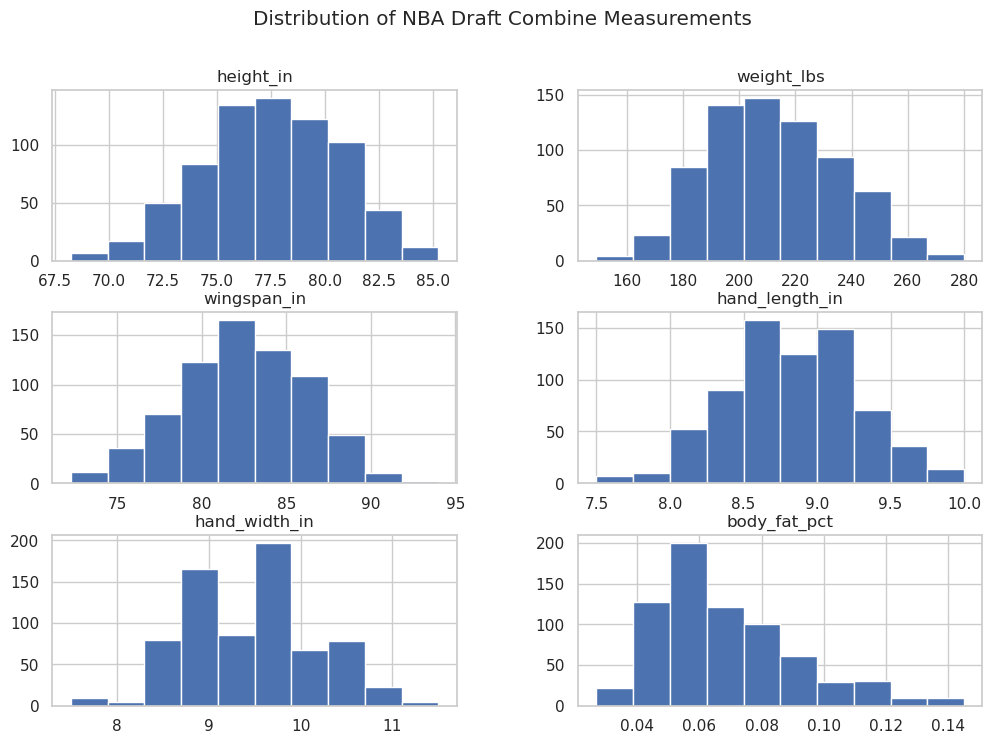

,height_in,weight_lbs,wingspan_in,hand_length_in,hand_width_in,body_fat_pct
count,711.000000,711.000000,711.000000,711.000000,711.000000,711.000000
mean,77.475387,212.068917,82.419972,8.711322,9.424895,0.068466
std,3.129555,22.915763,3.738406,0.451034,0.675183,0.022214
min,68.250000,149.200000,72.250000,7.500000,7.500000,0.027000
25%,75.375000,195.200000,79.750000,8.500000,9.000000,0.052000
50%,77.500000,210.200000,82.250000,8.750000,9.500000,0.063000
75%,79.750000,228.900000,85.250000,9.000000,9.800000,0.080000
max,85.250000,280.000000,94.000000,10.000000,11.500000,0.145000


In [12]:
sns.set(style="whitegrid")

df_clean.hist(figsize=(12,8))
plt.suptitle("Distribution of NBA Draft Combine Measurements")
plt.show()
df_clean.describe()

For Dataset #1, the summary statistics describe the overall physical profile of the 711 NBA Draft Combine players included in our cleaned dataset. On average, players measured about 77.48 inches tall, which is roughly 6 feet 5 and a half inches, and weighed approximately 212 pounds, showing that most prospects entering the draft are already well above average in both height and size. The average wingspan was about 82.42 inches, meaning that most players had a wingspan several inches longer than their height, which is an important physical advantage in basketball for defense and finishing at the rim.

Looking at hand measurements, the average hand length was about 8.71 inches and the average hand width was about 9.42 inches, which reflects the generally large hand size common among NBA prospects and can contribute to ball control and shooting ability. The average body fat percentage was approximately 6.85%, indicating that most players were in elite physical condition at the time of measurement.

The standard deviations show moderate variation across players, especially in weight and wingspan, meaning there is meaningful physical diversity within the sample. For example, heights ranged from 68.25 inches (about 5 feet 8 inches) to 85.25 inches (over 7 feet 1 inch), while wingspans ranged from 72.25 inches to 94 inches, demonstrating the wide range of body types entering the draft. Weight varied from about 149 pounds to 280 pounds, further showing positional and build differences among players. Body fat percentage ranged from 2.7% to 14.5%, which indicates that while most players are in top athletic shape, there are still differences in conditioning and body composition.

Overall, these summary statistics show that although NBA Draft prospects tend to share elite physical traits there is still substantial variation in size, reach, and body composition, which is important for our project because it allows us to analyze whether differences in these physical measurements are meaningfully related to draft position and long term NBA career success.

### Dataset #2
### 20 Years of NBA Draft Data from Kaggle

For Dataset #2, I am using NBA Draft data from Kaggle. This data shows players' draft year, college they played in, which team they were drafted to, and their overall draft rankings in the last 20 years. This data can be compared to dataset 3 to see their performance pre and post NBA. This dataset mainly focuses on their overall pick in the draft, but variables like position, draft year (who they were drafted with) can effect the result.

### A: Loading Data Set

In [13]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [14]:
raw_path = 'data/00-raw/draft-data-20-years.csv'
df_draft = pd.read_csv(raw_path)

print("Dataset Shape:", df_draft.shape)
print("\nColumns:\n", df_draft.columns)

df_draft.head()

Dataset Shape: (1868, 26)

Columns:
 Index(['Unnamed: 0', 'Rk', 'Pk', 'Tm', 'Player', 'College', 'Yrs', 'G',
       'TOTMP', 'TOTPTS', 'TOTTRB', 'TOTAST', 'FG%', '3P%', 'FT%', 'WS',
       'WS/48', 'BPM', 'VORP', 'DraftYr', 'MPG', 'PPG', 'RPG', 'APG',
       'playerurl', 'DraftYear'],
      dtype='object')


,Unnamed: 0,Rk,Pk,Tm,Player,College,Yrs,G,TOTMP,TOTPTS,...,WS/48,BPM,VORP,DraftYr,MPG,PPG,RPG,APG,playerurl,DraftYear
0,1,1,1,BRK,Derrick Coleman,Syracuse,15.0,781.0,25903.0,12884.0,...,0.119,1.4,22.3,1990,33.2,16.5,9.3,2.5,https://www.sports-reference.com/cbb/players/d...,1990
1,2,2,2,OKC,Gary Payton,Oregon State,17.0,1335.0,47117.0,21813.0,...,0.148,3.3,62.5,1990,35.3,16.3,3.9,6.7,https://www.sports-reference.com/cbb/players/g...,1990
2,3,3,3,DEN,Mahmoud Abdul-Rauf,LSU,9.0,586.0,15628.0,8553.0,...,0.077,-0.8,4.5,1990,26.7,14.6,1.9,3.5,https://www.sports-reference.com/cbb/players/m...,1990
3,4,4,4,ORL,Dennis Scott,Georgia Tech,10.0,629.0,17983.0,8094.0,...,0.089,0.2,9.9,1990,28.6,12.9,2.8,2.1,https://www.sports-reference.com/cbb/players/d...,1990
4,5,5,5,CHA,Kendall Gill,Illinois,15.0,966.0,29481.0,12914.0,...,0.078,0.1,15.8,1990,30.5,13.4,4.1,3.0,https://www.sports-reference.com/cbb/players/k...,1990


### B: Demonstrate tidiness / Checking for missing values 

In [15]:
# Checking if any of the values are missing 
missing_data = df_draft.isnull().sum()
print("Missing values per column:\n", missing_data)
display(df_draft.head())

Missing values per column:
 Unnamed: 0      0
Rk              0
Pk              0
Tm              0
Player          0
College       335
Yrs           247
G             247
TOTMP         247
TOTPTS        247
TOTTRB        247
TOTAST        247
FG%           252
3P%           368
FT%           284
WS            247
WS/48         248
BPM           248
VORP          247
DraftYr         0
MPG           247
PPG           247
RPG           247
APG           247
playerurl     335
DraftYear       0
dtype: int64


,Unnamed: 0,Rk,Pk,Tm,Player,College,Yrs,G,TOTMP,TOTPTS,...,WS/48,BPM,VORP,DraftYr,MPG,PPG,RPG,APG,playerurl,DraftYear
0,1,1,1,BRK,Derrick Coleman,Syracuse,15.0,781.0,25903.0,12884.0,...,0.119,1.4,22.3,1990,33.2,16.5,9.3,2.5,https://www.sports-reference.com/cbb/players/d...,1990
1,2,2,2,OKC,Gary Payton,Oregon State,17.0,1335.0,47117.0,21813.0,...,0.148,3.3,62.5,1990,35.3,16.3,3.9,6.7,https://www.sports-reference.com/cbb/players/g...,1990
2,3,3,3,DEN,Mahmoud Abdul-Rauf,LSU,9.0,586.0,15628.0,8553.0,...,0.077,-0.8,4.5,1990,26.7,14.6,1.9,3.5,https://www.sports-reference.com/cbb/players/m...,1990
3,4,4,4,ORL,Dennis Scott,Georgia Tech,10.0,629.0,17983.0,8094.0,...,0.089,0.2,9.9,1990,28.6,12.9,2.8,2.1,https://www.sports-reference.com/cbb/players/d...,1990
4,5,5,5,CHA,Kendall Gill,Illinois,15.0,966.0,29481.0,12914.0,...,0.078,0.1,15.8,1990,30.5,13.4,4.1,3.0,https://www.sports-reference.com/cbb/players/k...,1990


### C: Demonstrate the size of the dataset

In [16]:
print("Rows:", df_draft.shape[0])
print("Columns:", df_draft.shape[1])

Rows: 1868
Columns: 26


### D: Clean the Data

In [17]:
# Keeping important variables only to be used as columns (total of 6)
columns_to_keep = ['Player', 'DraftYr', 'Rk', 'Pk', 'College', 'Tm', 'WS', 'G']
df_draft_clean = df_draft[columns_to_keep].dropna(subset=['Pk'])
print("Final cleaned dataset shape:", df_draft_clean.shape)

Final cleaned dataset shape: (1868, 8)


### E: Detect Outliers or Suspicious Entries

In [18]:
# Since draft pick # range from 1 - 60, checking if any of the numbers are not in this range.
invalid_picks = df_draft_clean[(df_draft_clean['Pk'] < 1) | (df_draft_clean['Pk'] > 60)]
print(f"Invalid # draft picks found: {len(invalid_picks)}")

Invalid # draft picks found: 0


### F. Save Cleaned Dataset

In [19]:
processed_path_draft = 'data/02-processed/dataset_2_draft_clean.csv'
df_draft_clean.to_csv(processed_path_draft, index=False)

print("Cleaned dataset saved.")
df_draft_clean.head()

Cleaned dataset saved.


,Player,DraftYr,Rk,Pk,College,Tm,WS,G
0,Derrick Coleman,1990,1,1,Syracuse,BRK,64.3,781.0
1,Gary Payton,1990,2,2,Oregon State,OKC,145.5,1335.0
2,Mahmoud Abdul-Rauf,1990,3,3,LSU,DEN,25.2,586.0
3,Dennis Scott,1990,4,4,Georgia Tech,ORL,33.4,629.0
4,Kendall Gill,1990,5,5,Illinois,CHA,47.8,966.0


## Summary Statistic


In [20]:
stats_columns = ['Pk', 'WS', 'G']
summary_stats = df_draft_clean[stats_columns].describe()
summary_stats.loc['range'] = summary_stats.loc['max'] - summary_stats.loc['min']
print("Summary Statistics for NBA Draft Dataset (2000-2021)")
display(summary_stats.round(2))

Summary Statistics for NBA Draft Dataset (2000-2021)


,Pk,WS,G
count,1868.00,1621.00,1621.00
mean,29.76,17.58,342.48
std,16.95,27.86,322.95
min,1.00,-1.90,1.00
25%,15.00,0.40,69.00
50%,30.00,4.90,230.00
75%,44.00,23.80,575.00
max,60.00,248.30,1541.00
range,59.00,250.20,1540.00


This shows that:
- Pk mean is 29.76 and 50% (median) is 30, which means that the dataset is perfectly balanced since draft number range from 1 to 60.
- G is longevity, which shows that 25% of the drafted players do not make it through 69.0 games. This means that the draft failure rate is high. (should look at players who hit the 50% 230 games to compare to data from dataset 1)
- WS is Win shares, and mean being 17.58 and median 4.90 means that the data is right-skewed. Mean being 3 times higher than the median shows that most players in the NBA draft have low career impact and select few superstars bring the average up.

### Dataset #3
### NBA Players Stats since 1950s from Kaggle
 
For Dataset #3, I am using a dataset from Kaggle called NBA player stats. This dataset contains
individual statistics for each player across 67 seasons. There are many useful column variables to
work with for measuring a player’s career success, such as win shares, win shares per 48 games,
true shooting percentage, and more. However, since this dataset contains players from before the 2000s and
many of these statistics didn’t exist before then, we need to consider filtering these players out of
our data (dataset #2 also only contains players beyond 2000s, so we should filter out players before then). Additionally, since the dataset contains repeated entries of players due to it capturing the stats of players for every season, we need to sum up or average the stats of interest for their total career statistics. 

There many column variables in this dataset, including win shares, true shooting percentage, age, block percentage, free throw rate, etc. However, when measuring a player's career success, there are a few columns that can be major indicators. The columns we are most interested in are win shares, true shooting percentage, total career points, total games played, and total career minutes. 

The winshares are a cumulative statistic that estimates the exact number of team wins contributed by a player due to both their offense and defense. Essentially, they represent the overall impact on team success made by a player. The true shooting percentage measures how effectively a player scores, accounting for 2-pointers, 3-pointers and free throws in a single metric. This statistic represents the offensive efficiency of a player. The total points are the total points scored by the player throughout their career, which represents their raw offensive output. The total games represent the longetivity and durability by a player because it measures how long a player remained healthy throughout their career. The total minutes is how much time the player spent actually playing. which is why it represents the level of trust the player's coach has with the player and how big of a role they played for their teams. When we combine these statistics together, we are evaluating the overall success impact, offensive efficiency, volume of success, reliability, and longevity of a player, which effectively captures the player's career success. 



### A: Loading Data Set


In [21]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import os
# load both career and draft data to prepare for merge
raw_path = 'data/00-raw/draft-data-20-years.csv'
df_combine = pd.read_csv(raw_path)
df_career = pd.read_csv('data/00-raw/Seasons_Stats.csv')
# merge into dataframe with all players with both combine and career data
df_final = pd.merge(df_combine, df_career, on='Player', how='inner')

### B: Make the dataset tidy or demonstrate that it was already tidy

In [22]:
 # create a new dataframe with ONLY the columns we are interested in
my_columns = [
'Player', 'Draft_Year',
'G_y', 'MP', 'WS_y', 'TS%', 'PTS']
existing_cols = [c for c in my_columns if c in df_final.columns]
df_project1 = df_final[existing_cols].copy()
df_project1 = df_project1.rename(columns={
'G_y': 'Games',
'WS_y': 'Win_Shares',
'MP': 'Minutes',
'PTS': 'Points',
'TS%': 'True_Shooting'
})

In [23]:
 # Sum the volume stats and average the true shooting percentage
aggregations = {
'Games': 'sum',
'Minutes': 'sum',
'Win_Shares': 'sum',
'Points': 'sum',
'True_Shooting': 'mean'
}
# since this dataset shows each player's season stats, we want to sum all of their seasons stats into one single data for each player
df_project = df_project1.groupby('Player').agg(aggregations).reset_index()
df_project.head(10)

,Player,Games,Minutes,Win_Shares,Points,True_Shooting
0,A.J. Bramlett,8.0,61.0,-0.2,8.0,0.190000
1,A.J. English,151.0,3108.0,1.1,1502.0,0.480000
2,A.J. Guyton,80.0,1246.0,0.3,442.0,0.324000
3,A.J. Hammons,22.0,163.0,0.0,48.0,0.472000
4,A.J. Price,287.0,4253.0,5.0,1656.0,0.435000
5,Aaron Brooks,797.0,17088.0,23.2,7839.0,0.512267
6,Aaron Gordon,205.0,4958.0,10.1,1981.0,0.529333
7,Aaron Gray,387.0,4517.0,7.1,1235.0,0.525000
8,Aaron McKie,957.0,22594.0,44.9,6636.0,0.493059
9,Acie Earl,240.0,3012.0,0.3,1168.0,0.444333


### C: Demonstrate the size of the dataset

In [24]:
print(f"Dataset Dimensions: {df_project.shape}")
print(f"Rows (Players): {df_project.shape[0]}")
print(f"Columns (Variables): {df_project.shape[1]}")

Dataset Dimensions: (1221, 6)
Rows (Players): 1221
Columns (Variables): 6


### D: Investigate Missing Data

In [25]:
# Count missing values per column
missing_counts = df_project.isnull().sum()
print("\n--- Missing Data Analysis---")
print(missing_counts[missing_counts > 0]) # Only print columns with gaps

# Calculate percentage of missing data
print((missing_counts / len(df_project)) * 100)


--- Missing Data Analysis---
True_Shooting    3
dtype: int64
Player           0.0000
Games            0.0000
Minutes          0.0000
Win_Shares       0.0000
Points           0.0000
True_Shooting    0.2457
dtype: float64


### E: Detect Outliers or Suspicious Entries

In [26]:
numeric_cols = ['Games', 'Minutes', 'Win_Shares', 'Points', 'True_Shooting']
print("---Outlier Detection Report---")
# detect outlier using the interquartile method
for col in numeric_cols:
    
# calculate quartiles
    Q1 = df_project[col].quantile(0.25)
    Q3 = df_project[col].quantile(0.75)
    IQR = Q3- Q1
    lower_bound = Q1- 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

# Find the outliers
outliers = df_project[(df_project[col] < lower_bound) | (df_project[col] > upper_bound)]

# Print findings
print(f"\n Variable: {col}")
print(f"- Normal Range: {lower_bound:.2f} to {upper_bound:.2f}")
print(f"- Outliers Found: {len(outliers)}")

# Show the top 3 biggest outliers
if not outliers.empty:
    print(f"- Top 3 Outliers:")
    print(outliers[['Player', col]].sort_values(by=col, ascending=False).head(3).to_string(index=False))
    print("\n-----------------------------")
    
suspicious_negatives = ['Games', 'Minutes', 'Points'] #cannot be negative here, (note that win shares can be negtative if a player performs bad enough)
print("--- Suspicious Value Check (Negative Values)---\n")

# Check for the strictly positive columns
for col in suspicious_negatives:
    # Filter for values less than 0
    negative_values = df_project[df_project[col] < 0]
if len(negative_values) > 0:
    print(f"\nFound {len(negative_values)} negative values in '{col}'")
    print(negative_values[['Player', col]])
else:
    print(f"'{col}': No negative values found. (Clean)\n")
    print("------------------------------------------")

---Outlier Detection Report---

 Variable: True_Shooting
- Normal Range: 0.35 to 0.64
- Outliers Found: 73
- Top 3 Outliers:
        Player  True_Shooting
 Tyson Wheeler          1.064
Chad Gallagher          1.000
 Randy Holcomb          1.000

-----------------------------
--- Suspicious Value Check (Negative Values)---

'Points': No negative values found. (Clean)

------------------------------------------


### F: Clean the Data

In [27]:
# Fill missingnumeric stats with 0
cols_to_fix= ['Games', 'Minutes', 'Win_Shares','Points', 'True_Shooting']
for col in cols_to_fix:
    df_project[col]= df_project[col].fillna(0)

# Verify cleaning
print(f"\nMissing values after cleaning: {df_project.isnull().sum().sum()}")


Missing values after cleaning: 0


### G. Save Cleaned Dataset

In [28]:
processed_path_career= 'data/02-processed/dataset_3_career_clean.csv'

df_project.to_csv(processed_path_career,index=False)

print("Cleaned dataset saved.")

Cleaned dataset saved.


### Summary Statistics of Dataset #3

In [29]:
summary = df_project.describe().round(2)

print("\n--- Summary Statistics (Career Data)---")
print(summary)
print("\n")


--- Summary Statistics (Career Data)---
         Games   Minutes  Win_Shares    Points  True_Shooting
count  1221.00   1221.00     1221.00   1221.00        1221.00
mean    388.89   9280.51       19.03   3828.40           0.49
std     353.64  10584.35       28.45   4991.04           0.09
min       1.00      0.00       -2.40      0.00           0.00
25%      80.00    931.00        0.50    285.00           0.46
50%     279.00   5144.00        6.40   1801.00           0.50
75%     628.00  14742.00       26.90   5728.00           0.53
max    1884.00  54981.00      206.30  33643.00           1.06




What this means:

These summary statistics show a right-skewed distribiution in player performance, where the “average” entry represents a player who plays around 389 games and scores a total of 3828 points in their career, where as the 50% median is lower at around 1801 points. This data also shows that there is a major gap between typical players and elite players, where the top 25% of players generate an impressive 206.30 winshares and 33,643 total points, which is disproportionately greater than the rest. This is the reason why the mean is noticeably greater than the median; the elite players are skewing the avergae up. The maximum values, such as 33,643 points, align with historical NBA records which confirms the data cleaning and tidying process.

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - Physical Player Traits Vs Draft Pick and Career Success

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

Physical Player Traits vs Draft Pick

In [30]:
# Enable autoreload for our custom modules
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Append the modules directory to the system path
sys.path.append('./modules')
import eda_utils # Custom module we will create for repetitive tasks

# 1. Load the processed datasets
combine_df = pd.read_csv('data/02-processed/draft_combine_body_measurements.csv')
draft_df = pd.read_csv('data/02-processed/dataset_2_draft_clean.csv')
career_df = pd.read_csv('data/02-processed/dataset_3_career_clean.csv')

# Preview the successful load
print(f"Combine Data: {combine_df.shape}")
print(f"Draft Data: {draft_df.shape}")
print(f"Career Data: {career_df.shape}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Combine Data: (711, 8)
Draft Data: (1868, 8)
Career Data: (1221, 6)


First, we want to understand how a player's physical measurements influence their overall draft ranking (`Pk`). By merging our combine dataset with our draft dataset, we can observe if the NBA draft prioritize factors like `height_in` or `wingspan_in` when making early draft picks.

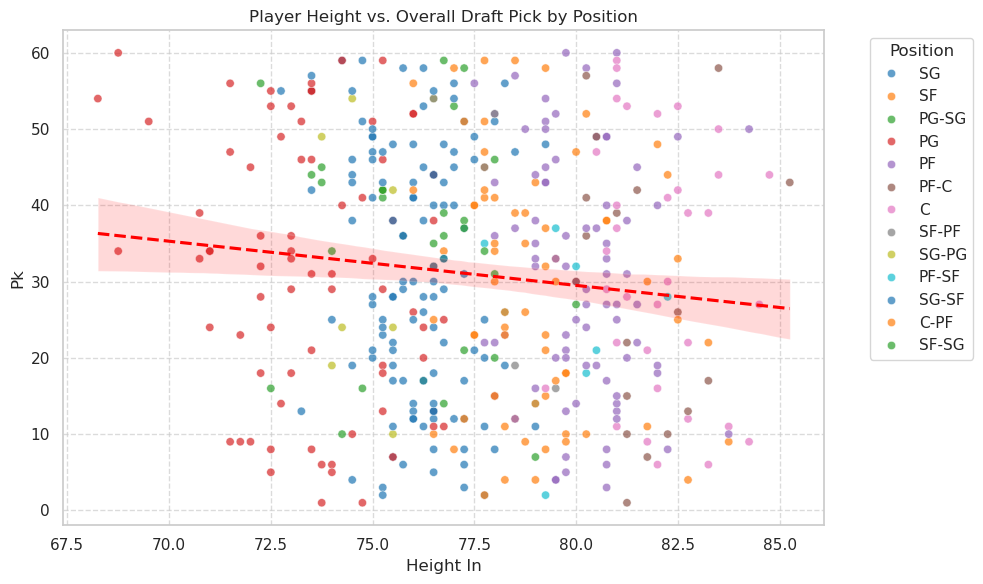

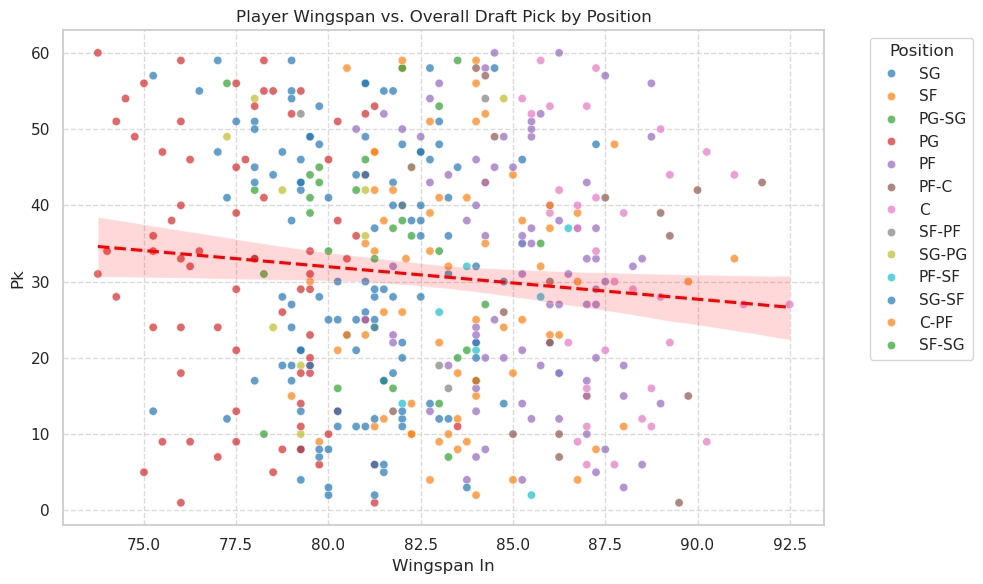

In [31]:

draft_combine_merged = pd.merge(draft_df, combine_df, on='Player', how='inner')

# Plot Height vs. Draft Pick, colored by Position
eda_utils.plot_feature_vs_target(
    df=draft_combine_merged, 
    feature_col='height_in', 
    target_col='Pk', 
    title='Player Height vs. Overall Draft Pick by Position',
    hue_col='Position'
)

# Plot Wingspan vs. Draft Pick, colored by Position
eda_utils.plot_feature_vs_target(
    df=draft_combine_merged, 
    feature_col='wingspan_in', 
    target_col='Pk', 
    title='Player Wingspan vs. Overall Draft Pick by Position',
    hue_col='Position'
)

The scatter plots above reveal a wide. variance and a seemingly weak relationship between physical measurements and overall draft pick. Here, 'Pk' represents how early the player was picked in the draft, so a lower number means better. Therefore, the slightly downward regression line indicates a small trend where taller and wider wingspan players are drafter earlier. However, the massive spread of data points shows that NBA draft placements are influenced by more than just physical attributes, such as skill, college performance and team needs. There is also a confounding variable which is player position. For instance, a 6'6" point guard (considered tall for a point guard) might be drafted much earlier than a 6'6" center (considered small for a center), which is why we have taken position into account as well. 

Based on the positions, we can see that there are more centers and power forwards (the positions who need bigger players) that have lower draft picks who are very tall and have wide wingspans. Around the middle, we can see many small forwards and shooting guards near the bottom, which makes sense considering that their positions are suited for 'medium' sized players. Then, around the 6 foot 2, and 75-78 inch wingspan range, we can see more point guards near the bottom. This shows that the judges in draft picks prefer players whose builds are suited for their position, and not to mention that it is rare to see point guards who are very tall, or centers that are very small, etc. 

Physical Traits vs Long-Term NBA Success

Since draft position is just an initial evaluation, a more accurate  measure of an NBA player's success can be defined by their longevity (`Games`), scoring (`Points`), and overall impact (`Win_Shares`). Therefore, we will merge our combined physical data with the career stats dataset to see if traits like `body_fat_pct` or `wingspan_in` have a statistical relationship with a player's long-term value.

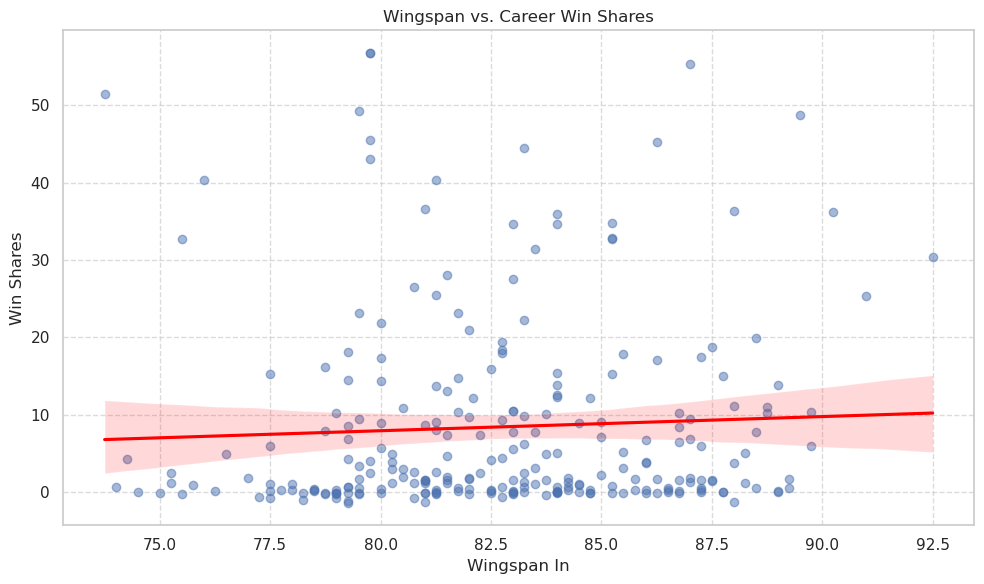

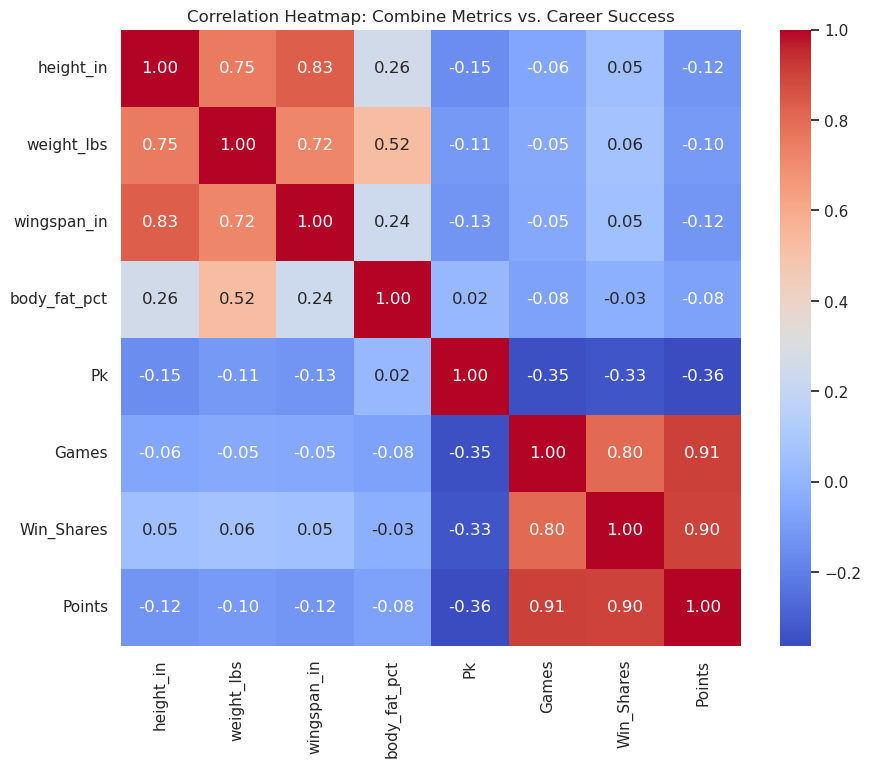

In [32]:
# Merge the previously merged draft/combine dataframe with career stats
full_merged_df = pd.merge(draft_combine_merged, career_df, on='Player', how='inner')

# Drop any potential NaN values created during the merge
full_merged_df.dropna(subset=['Win_Shares', 'Games', 'wingspan_in'], inplace=True)

# Plot Wingspan against Career Win Shares
eda_utils.plot_feature_vs_target(
    df=full_merged_df, 
    feature_col='wingspan_in', 
    target_col='Win_Shares', 
    title='Wingspan vs. Career Win Shares'
)

# Correlation matrix for a more holistic view of numerical features
plt.figure(figsize=(10, 8))
correlation_cols = ['height_in', 'weight_lbs', 'wingspan_in', 'body_fat_pct', 'Pk', 'Games', 'Win_Shares', 'Points']
sns.heatmap(full_merged_df[correlation_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Combine Metrics vs. Career Success")
plt.show()

## Draft Position and Career Performance

I think it is necessary to understand the role of the draft position itself before exploring further whether the results of the NBA combine metrics can predict a player's first five years of professional success.

The draft position generally reflects the assessment of each team's overall potential of the player, which is based on factors such as the player's college performance and physical traits. Players ranked higher in the draft usually receive more opportunities and better contracts. Therefore, the draft position is likely to have a significant impact on a player's career performance.

In this section, I will explore the relationship between draft position (`Pk`) and several indicators of NBA career performance, including total games played, career win shares, and total points scored. This analysis helps establish whether draft position is associated with career success and why it should be considered when evaluating the impacts of combine measurements.

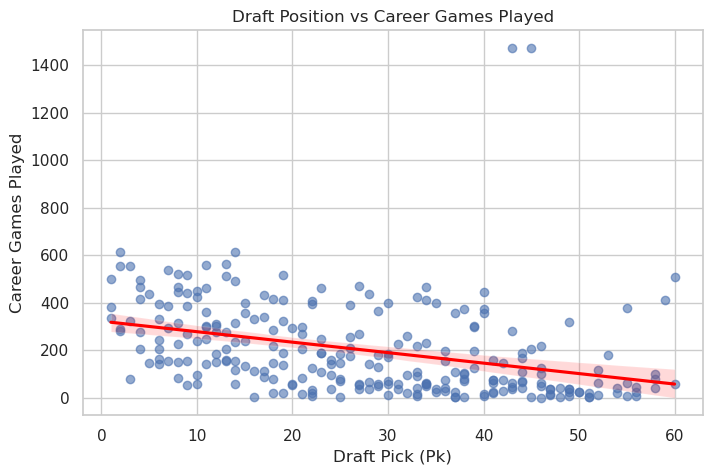

In [33]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=full_merged_df,
    x='Pk',
    y='Games',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'})

plt.title("Draft Position vs Career Games Played")
plt.xlabel("Draft Pick (Pk)")
plt.ylabel("Career Games Played")

plt.show()

The above scatter plot shows a relatively weak relationship between draft position and career games played. And 'Pk' represents how early the player was picked in the draft, so a lower number means better. The red regression line indicates a negative trend, suggesting that players who get picked earlier tend to play more games over their careers, likely due to better opportunities and stronger team investment influenced by the draft position.

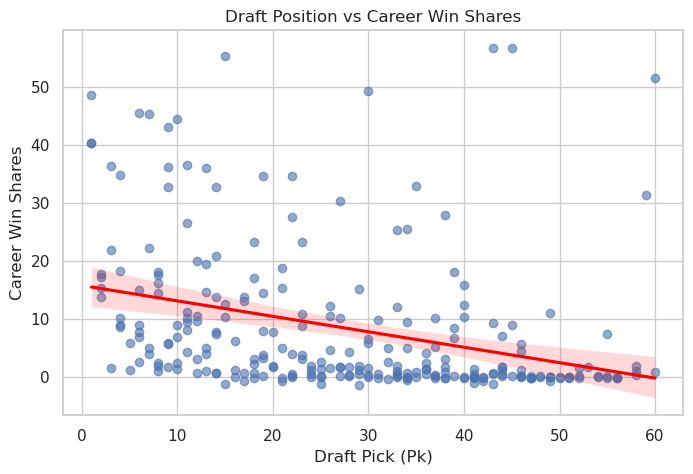

In [34]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=full_merged_df,
    x='Pk',
    y='Win_Shares',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title("Draft Position vs Career Win Shares")
plt.xlabel("Draft Pick (Pk)")
plt.ylabel("Career Win Shares")

plt.show()

This scatter plot illustrates the relationship between the draft position and the career win share. The win share is a used to estimate the number of winning games that a player has contributed to their team during their career.
The negative regression trend shows that players selected earlier tend to contribute more win shares. Hence, the draft position can reflect important information about a player's level and their long-term influence in the league.

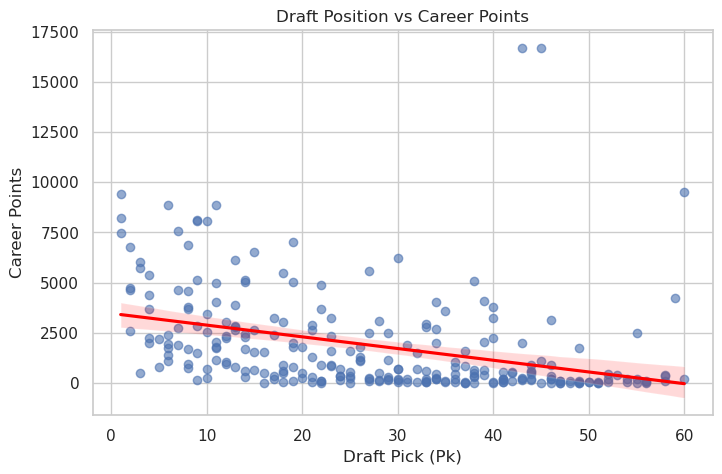

In [35]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=full_merged_df,
    x='Pk',
    y='Points',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title("Draft Position vs Career Points")
plt.xlabel("Draft Pick (Pk)")
plt.ylabel("Career Points")

plt.show()

This plot illustrates the relationship between the draft position and the total career scoring of players. The total career scoring is a very good indicator, which can reflect the offensive contribution accumulated by a player throughout their career. The negative trend presented in this plot indicates that players who get picked early in the draft tend to score more throughout their careers. However, this relationship is not as strong as Career Win shares. This might be related to the fact that early draft picks usually get more playing opportunities, especially in the early stages of their careers, which helps them score more.

In [36]:
# Create draft pick groups
full_merged_df['Draft_Group'] = pd.cut(
    full_merged_df['Pk'],
    bins=[0,14,30,100],
    labels=['Lottery (1-14)', 'Mid First Round (15-30)', 'Late Picks (31+)']
)

full_merged_df['Draft_Group'].value_counts()

Draft_Group
Late Picks (31+)           111
Mid First Round (15-30)     75
Lottery (1-14)              70
Name: count, dtype: int64

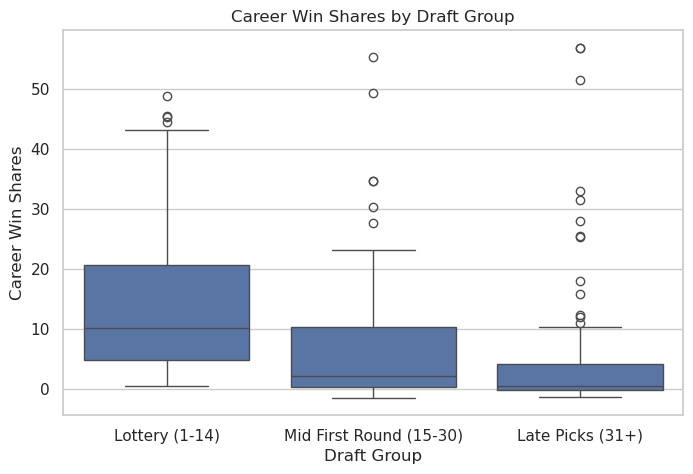

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=full_merged_df,
    x='Draft_Group',
    y='Win_Shares'
)

plt.title("Career Win Shares by Draft Group")
plt.xlabel("Draft Group")
plt.ylabel("Career Win Shares")

plt.show()

In order to see the relationship between draft position and career performance more clearly, I will put players into three groups based on their draft position: lottery picks (1–14), mid-first-round picks (15–30), and later selections (31+).

The above boxplot obviously shows that lottery picks have higher median win shares compared to players selected later in the draft. This suggests that players picked earlier generally contribute more to team success over their careers.

However, the wide distribution and presence of outliers indicate that draft position alone does not fully determine career success. Some later picks still achieve high levels of performance, showing the variability in player development, and there should be some other factors that influenced one player's performance.

Overall, draft position is moderately associated with several indicators of career performance, including games played, win shares, and total points. Because draft position appears to be related to long-term career outcomes, it should be considered when evaluating whether NBA Draft Combine measurements provide additional predictive value for player success.

#### Section 2 of EDA if you need it  - please give it a better title than this

Here, we will be analyzing how the draft picking (aka RK) of the athletes would end up correlating with their careers feats. This would include feats such as games played, points made, and win shares. By merging our combine dataset with our draft dataset, we can observe if the NBA draft correlates to factors as the feats mentioned before.

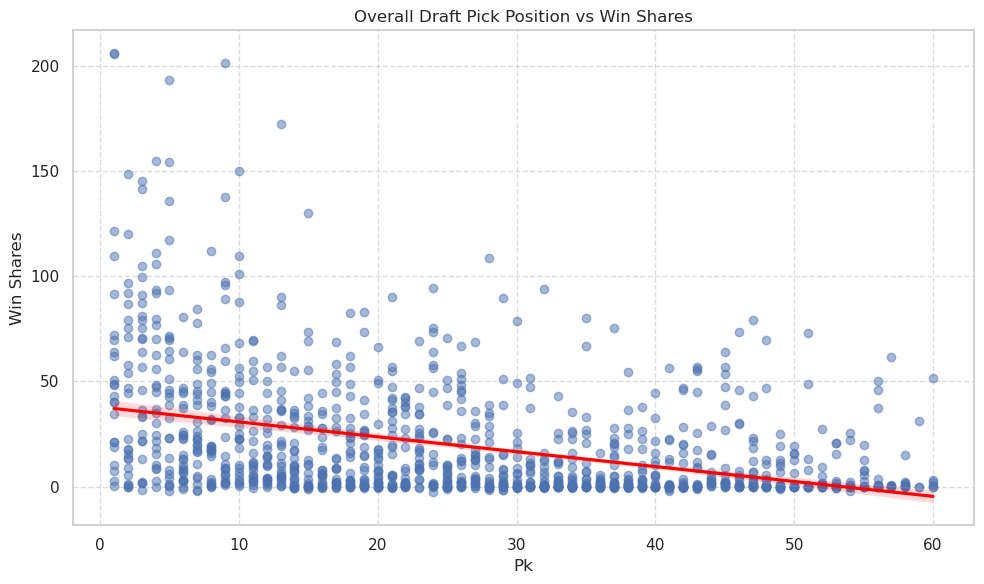

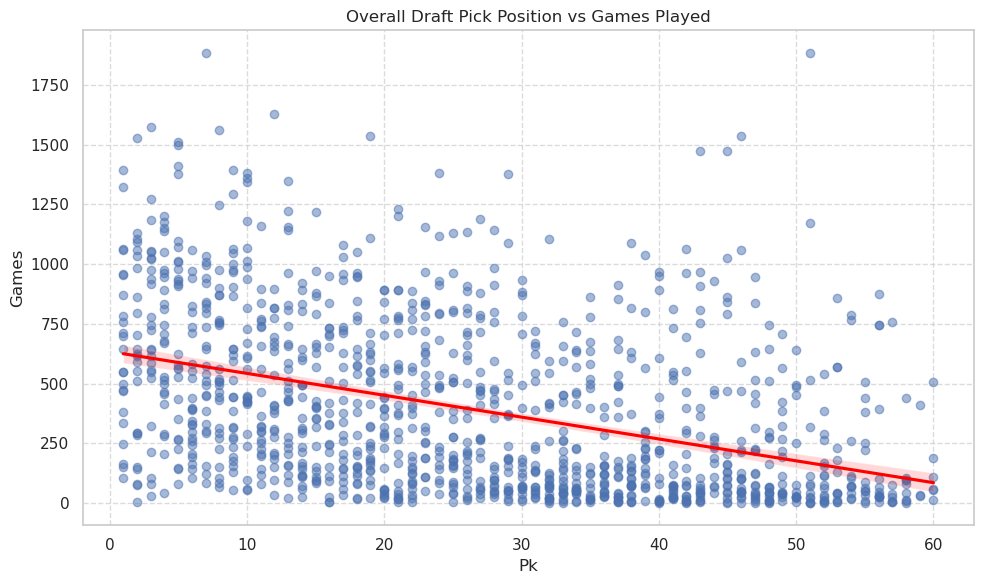

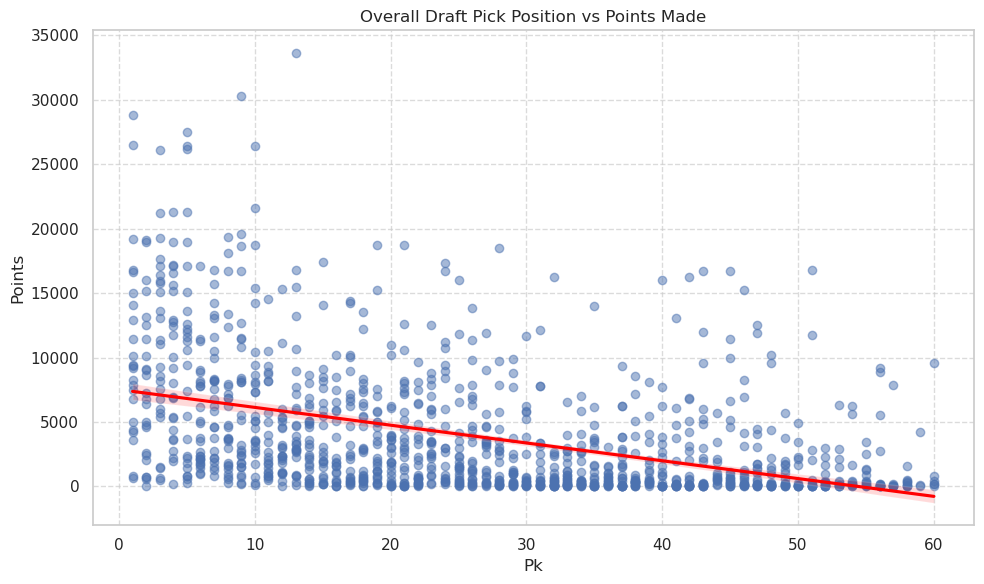

In [40]:
draft_combine_merged2 = pd.merge(career_df, draft_df, on='Player', how='inner')

# Plot Height vs. Draft Pick, colored by Position
eda_utils.plot_feature_vs_target(
    df=draft_combine_merged2, 
    feature_col='Pk', 
    target_col='Win_Shares', 
    title='Overall Draft Pick Position vs Win Shares',
    hue_col='Position'
)

# Plot Wingspan vs. Draft Pick, colored by Position
eda_utils.plot_feature_vs_target(
    df=draft_combine_merged2, 
    feature_col='Pk', 
    target_col='Games', 
    title='Overall Draft Pick Position vs Games Played',
    hue_col='Position'
)

eda_utils.plot_feature_vs_target(
    df=draft_combine_merged2, 
    feature_col='Pk', 
    target_col='Points', 
    title='Overall Draft Pick Position vs Points Made',
    hue_col='Position'
)

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them